### Data Loading & Input Schema
This part loads raw Uniswap V3 interaction logs and prepares them for analysis.

* **Input Columns**:
    * `datetime`: UTC timestamp of the event.
    * `blockNumber`: Ethereum block height. Used for precise chronological ordering.
    * `event`: Action type.
    * `WETH` / `USDC`: The token amounts transacted in the event.
* `tick`: The active price tick at the moment of the event ($Price = 1.0001^{tick}$).
    * `price`: The spot price of the pool at that block.
    * `liquidity`: The amount of liquidity value in the swap event.
    * `tickLower` / `tickUpper`: The price range boundaries chosen by the LP.
    * `amount`: liquidity value in the mint or burn event.



In [3]:
import importlib
import data_loader
import features
import clustering
import performance
importlib.reload(data_loader)
importlib.reload(features)
importlib.reload(clustering)
importlib.reload(performance)
from data_loader import load_liquidity_data, process_csv
from features import calculate_features, calculate_Lx, normalize_and_save
from clustering import run_kmeans_clustering, calculate_dependent_variables, analyze_and_plot_correlations, analyze_and_plot_robust_correlations
from performance import calculate_sharpe_and_plot, plot_pca_clusters, analyze_optimal_k, visualize_clusters, analyze_cluster_performance
import pandas as pd
import numpy as np
import os
import glob
import json
from datetime import datetime, timezone

In [8]:
# 1. read config
# In this notebook, we use WETH_USDC pool on arbitrum with 0.05% fee tier
config_files = "config/WETH_USDC_arbitrum_config.json"
with open(config_files, 'r') as f:
    conf = json.load(f)

pool_address = conf["pool_address"]
chain = conf["chain"]
token0 = conf["token0"]
token1 = conf["token1"]
decimal_0 = conf["decimal_0"]
decimal_1 = conf["decimal_1"]
tickspacing = conf["tickspacing"]
base_symbol = conf["base_symbol"]
quote_symbol = conf["quote_symbol"]
fee_tier = conf["fee_tier"]
pool_name = token0 + "_" + token1 + "_" + chain
start_date_str = "2024-09-01T00:00:00Z"
end_date_str = "2025-03-01T00:00:00Z"
start_timestamp = int(pd.to_datetime(start_date_str).timestamp())
end_timestamp = int(pd.to_datetime(end_date_str).timestamp())

# load data from teahouse api
# the data is saved in data folder
# df_lp_total = load_liquidity_data(pool_address, chain, start_timestamp, end_timestamp, save=True)

In [42]:
# load data from csv
df_lp_total = process_csv(file_pattern="data/data_*.csv", token0=token0, token1=token1, decimal_0=decimal_0, decimal_1=decimal_1)
df_lp_total

c:\Users\shihf\AMM_analysis\ClusterLOB\data_loader.py:73: DtypeWarning: Columns (5,7) have mixed types. Specify dtype option on import or set low_memory=False.
  list_of_dfs = [pd.read_csv(f) for f in file_list]
c:\Users\shihf\AMM_analysis\ClusterLOB\data_loader.py:73: DtypeWarning: Columns (5,7) have mixed types. Specify dtype option on import or set low_memory=False.
  list_of_dfs = [pd.read_csv(f) for f in file_list]
c:\Users\shihf\AMM_analysis\ClusterLOB\data_loader.py:73: DtypeWarning: Columns (5,7) have mixed types. Specify dtype option on import or set low_memory=False.
  list_of_dfs = [pd.read_csv(f) for f in file_list]
c:\Users\shihf\AMM_analysis\ClusterLOB\data_loader.py:73: DtypeWarning: Columns (5,7) have mixed types. Specify dtype option on import or set low_memory=False.
  list_of_dfs = [pd.read_csv(f) for f in file_list]
c:\Users\shihf\AMM_analysis\ClusterLOB\data_loader.py:73: DtypeWarning: Columns (5,7) have mixed types. Specify dtype option on import or set low_memory

,datetime,blockNumber,event,WETH,USDC,amount,tick,price,liquidity,tickLower,tickUpper,current_tick,current_liquidity,current_price
0,2021-09-01 00:20:48+00:00,228962.0,Mint,0.001301,3.371855,229961494372.0,NaN,NaN,NaN,-200310.0,-186450.0,NaN,NaN,NaN
1,2021-09-01 01:11:38+00:00,229112.0,Mint,0.285168,1346.888839,273489084741947.0,NaN,NaN,NaN,-196370.0,-193360.0,NaN,NaN,NaN
2,2021-09-01 01:21:29+00:00,229166.0,Mint,0.010000,0.000000,3720326698897.0,NaN,NaN,NaN,-194630.0,-191150.0,NaN,NaN,NaN
3,2021-09-01 01:43:47+00:00,229343.0,Swap,0.010000,-35.174193,NaN,-194682.0,3511.485552,274638854033545.0,NaN,NaN,-194682.0,2.746389e+14,3511.485552
4,2021-09-01 01:58:45+00:00,229515.0,Swap,0.010000,-35.022775,NaN,-194725.0,3496.419333,273719046236319.0,NaN,NaN,-194725.0,2.737190e+14,3496.419333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19947462,2025-08-31 23:57:10+00:00,374383299.0,Swap,-0.081091,356.200369,NaN,-192448.0,4390.433691,112784687196814480.0,NaN,NaN,-192448.0,1.127847e+17,4390.433691
19947464,2025-08-31 23:58:45+00:00,374383685.0,Burn,0.000000,0.000000,0.0,NaN,NaN,NaN,-193870.0,-193470.0,-192448.0,1.127847e+17,4390.433691
19947465,2025-08-31 23:58:46+00:00,374383689.0,Swap,-0.038167,167.666298,NaN,-192448.0,4390.433691,112784687196814480.0,NaN,NaN,-192448.0,1.127847e+17,4390.433691
19947466,2025-08-31 23:59:49+00:00,374383942.0,Swap,-0.070115,308.029397,NaN,-192447.0,4390.872734,112784687196814480.0,NaN,NaN,-192447.0,1.127847e+17,4390.872734


### Feature Engineering

In [43]:
# Feature Engineering
# Calculate base features (S_x, V_x, etc.)
df_lp_total = calculate_features(df_lp_total, token0, token1, decimal_0, decimal_1, tickspacing, base_symbol)
df_lp_total[df_lp_total['event'].isin(['Mint', 'Burn'])]

Calculating S(x)
Calculating Delta_T(x) & V(x)
Calculating D_L(x) & D_U(x)


,datetime,blockNumber,event,WETH,USDC,amount,tick,price,liquidity,tickLower,tickUpper,current_tick,current_liquidity,current_price,S_x,Delta_T_x,V_x,D_L_x,D_U_x
0,2021-09-01 00:20:48+00:00,228962.0,Mint,0.001301,3.371855,229961494372.0,NaN,NaN,NaN,-200310.0,-186450.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-09-01 01:11:38+00:00,229112.0,Mint,0.285168,1346.888839,273489084741947.0,NaN,NaN,NaN,-196370.0,-193360.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-09-01 01:21:29+00:00,229166.0,Mint,0.010000,0.000000,3720326698897.0,NaN,NaN,NaN,-194630.0,-191150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2021-09-01 02:18:02+00:00,229707.0,Mint,0.010000,21.842890,956484076023924.0,NaN,NaN,NaN,-195160.0,-195140.0,-195153.0,2.737190e+14,3349.936991,3.494401,27.0,342.086310,0.0,0.0
8,2021-09-01 02:55:49+00:00,230139.0,Burn,0.000000,216.544925,4813078937717367.0,NaN,NaN,NaN,-200200.0,-200180.0,-195153.0,2.737190e+14,3349.936991,0.0,2294.0,342.086310,-5047.0,-5027.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19946783,2025-08-31 22:37:48+00:00,374364235.0,Mint,0.233091,3094.698019,155761811078790.0,NaN,NaN,NaN,-199360.0,-190190.0,-192296.0,1.145762e+17,4457.674658,0.001359,195.0,2136.010233,0.0,0.0
19946841,2025-08-31 22:46:10+00:00,374366242.0,Burn,0.046371,197.295037,64888107941361.0,NaN,NaN,NaN,-193260.0,-191350.0,-192327.0,1.144849e+17,4443.877952,0.000567,173.0,4947.119754,0.0,0.0
19946989,2025-08-31 23:06:14+00:00,374371058.0,Burn,0.000000,0.000000,0.0,NaN,NaN,NaN,-193180.0,-191130.0,-192346.0,1.143944e+17,4435.443021,0.0,13.0,1897.150218,0.0,0.0
19946992,2025-08-31 23:06:14+00:00,374371058.0,Mint,0.000658,2.023982,743435244993.0,NaN,NaN,NaN,-193180.0,-191130.0,-192346.0,1.143944e+17,4435.443021,0.000006,13.0,1897.398918,0.0,0.0


In [49]:
# Calculate L(x)
df_lp_total = calculate_Lx(df_lp_total, token0, token1, decimal_0, decimal_1, tickspacing, base_symbol)

Calculating L(x)


* In this notebook, we analyze the performance during the period of 2024-09-01 to 2025-09-01
* Train set is from 2024-09-01 to 2025-03-01
* Test set is from 2025-03-01 to 2025-09-01

In [50]:
# filt perticular time period data 
file_path = 'data_feature\data_total.csv'
chunk_size = 1000000
start_date = pd.to_datetime("2024-08-01T00:00:00Z")
end_date = pd.to_datetime("2025-09-01T00:00:00Z")

chunks = []
for i, chunk in enumerate(pd.read_csv(file_path, chunksize=chunk_size)):
    chunk['datetime'] = pd.to_datetime(chunk['datetime'], utc=True)
    mask = (chunk['datetime'] >= start_date) & (chunk['datetime'] < end_date)
    filtered_chunk = chunk[mask].copy()
    chunks.append(filtered_chunk)
df_final = pd.concat(chunks, ignore_index=True)

In [51]:
df_final[df_final['event'].isin(['Mint', 'Burn'])]

,datetime,blockNumber,event,WETH,USDC,amount,tick,price,liquidity,tickLower,tickUpper,current_tick,current_liquidity,current_price,S_x,Delta_T_x,V_x,D_L_x,D_U_x,L_x
0,2024-08-01 00:00:05+00:00,238132789.0,Burn,0.000000,0.000000,0.000000e+00,NaN,NaN,NaN,-196760.0,-193760.0,-195512.0,7.614433e+17,3231.813167,0.000000,660.0,32466.281964,0.0,0.0,0.000000e+00
4,2024-08-01 00:00:29+00:00,238132882.0,Burn,44.139095,0.000000,6.565717e+16,NaN,NaN,NaN,-195000.0,-194200.0,-195512.0,7.614433e+17,3231.813167,0.000000,684.0,32550.538144,512.0,1312.0,1.602500e+06
5,2024-08-01 00:00:29+00:00,238132882.0,Mint,44.139095,0.000000,6.562435e+16,NaN,NaN,NaN,-195010.0,-194210.0,-195512.0,7.614433e+17,3231.813167,0.000000,684.0,32550.538144,502.0,1302.0,1.573853e+06
6,2024-08-01 00:00:29+00:00,238132882.0,Burn,0.000000,0.000000,0.000000e+00,NaN,NaN,NaN,-195000.0,-194200.0,-195512.0,7.614433e+17,3231.813167,0.000000,684.0,32550.538144,512.0,1312.0,1.604318e+06
8,2024-08-01 00:01:26+00:00,238133108.0,Burn,0.002731,5.298140,2.538884e+12,NaN,NaN,NaN,-196260.0,-194250.0,-195512.0,7.614433e+17,3231.813167,0.000003,741.0,32575.451789,0.0,0.0,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5264962,2025-08-31 22:37:48+00:00,374364235.0,Mint,0.233091,3094.698019,1.557618e+14,NaN,NaN,NaN,-199360.0,-190190.0,-192296.0,1.145762e+17,4457.674658,0.001359,195.0,2136.010233,0.0,0.0,0.000000e+00
5265020,2025-08-31 22:46:10+00:00,374366242.0,Burn,0.046371,197.295037,6.488811e+13,NaN,NaN,NaN,-193260.0,-191350.0,-192327.0,1.144849e+17,4443.877952,0.000567,173.0,4947.119754,0.0,0.0,0.000000e+00
5265167,2025-08-31 23:06:14+00:00,374371058.0,Burn,0.000000,0.000000,0.000000e+00,NaN,NaN,NaN,-193180.0,-191130.0,-192346.0,1.143944e+17,4435.443021,0.000000,13.0,1897.150218,0.0,0.0,0.000000e+00
5265169,2025-08-31 23:06:14+00:00,374371058.0,Mint,0.000658,2.023982,7.434352e+11,NaN,NaN,NaN,-193180.0,-191130.0,-192346.0,1.143944e+17,4435.443021,0.000006,13.0,1897.398918,0.0,0.0,0.000000e+00


In [52]:
# Normalize and Save
df_final_norm = normalize_and_save(df_final, "2024-09-01T00:00:00Z","2025-09-01T00:00:00Z", output_file = "data_feature/data_norm_features.csv")
df_final_norm[df_final_norm["event"].isin({'Mint','Burn'})]

,datetime,blockNumber,event,WETH,USDC,amount,tick,price,liquidity,tickLower,...,V_x,D_L_x,D_U_x,L_x,S_x_norm,Delta_T_x_norm,V_x_norm,D_L_x_norm,D_U_x_norm,L_x_norm
680102,2024-09-01 00:16:01+00:00,248790511.0,Burn,0.000000,0.000000,0.000000e+00,NaN,NaN,NaN,-198610.0,...,20339.601147,0.0,0.0,0.000000,-0.167905,0.926593,0.241216,-0.046383,-0.238414,-0.429158
680106,2024-09-01 00:16:42+00:00,248790675.0,Burn,0.000000,0.000000,0.000000e+00,NaN,NaN,NaN,-198620.0,...,2516.095639,0.0,0.0,0.000000,-0.167905,-0.881999,-1.043135,-0.046383,-0.238414,-0.429158
680108,2024-09-01 00:17:07+00:00,248790774.0,Burn,0.000000,0.000000,0.000000e+00,NaN,NaN,NaN,-197790.0,...,2517.344675,230.0,1030.0,486136.859923,-0.167905,-0.799629,-1.026018,0.204979,0.398111,0.153626
680109,2024-09-01 00:17:41+00:00,248790907.0,Burn,0.000000,0.000000,0.000000e+00,NaN,NaN,NaN,-198630.0,...,2517.344675,0.0,0.0,0.000000,-0.167905,-0.693587,-1.009333,-0.048913,-0.244718,-0.435401
680112,2024-09-01 00:18:13+00:00,248791034.0,Burn,0.000000,0.000000,0.000000e+00,NaN,NaN,NaN,-198640.0,...,2560.642385,0.0,0.0,0.000000,-0.167905,-0.588127,-0.989310,-0.097768,-0.276220,-0.419235
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5264962,2025-08-31 22:37:48+00:00,374364235.0,Mint,0.233091,3094.698019,1.557618e+14,NaN,NaN,NaN,-199360.0,...,2136.010233,0.0,0.0,0.000000,-0.118209,0.041585,-0.212966,0.100000,0.100000,-0.100000
5265020,2025-08-31 22:46:10+00:00,374366242.0,Burn,0.046371,197.295037,6.488811e+13,NaN,NaN,NaN,-193260.0,...,4947.119754,0.0,0.0,0.000000,-0.176263,-0.078225,1.064293,0.100000,0.100000,-0.100000
5265167,2025-08-31 23:06:14+00:00,374371058.0,Burn,0.000000,0.000000,0.000000e+00,NaN,NaN,NaN,-193180.0,...,1897.150218,0.0,0.0,0.000000,-0.217471,-0.910584,-0.338434,0.100000,0.100000,-0.100000
5265169,2025-08-31 23:06:14+00:00,374371058.0,Mint,0.000658,2.023982,7.434352e+11,NaN,NaN,NaN,-193180.0,...,1897.398918,0.0,0.0,0.000000,-0.217003,-0.899839,-0.330132,0.100000,0.100000,-0.100000


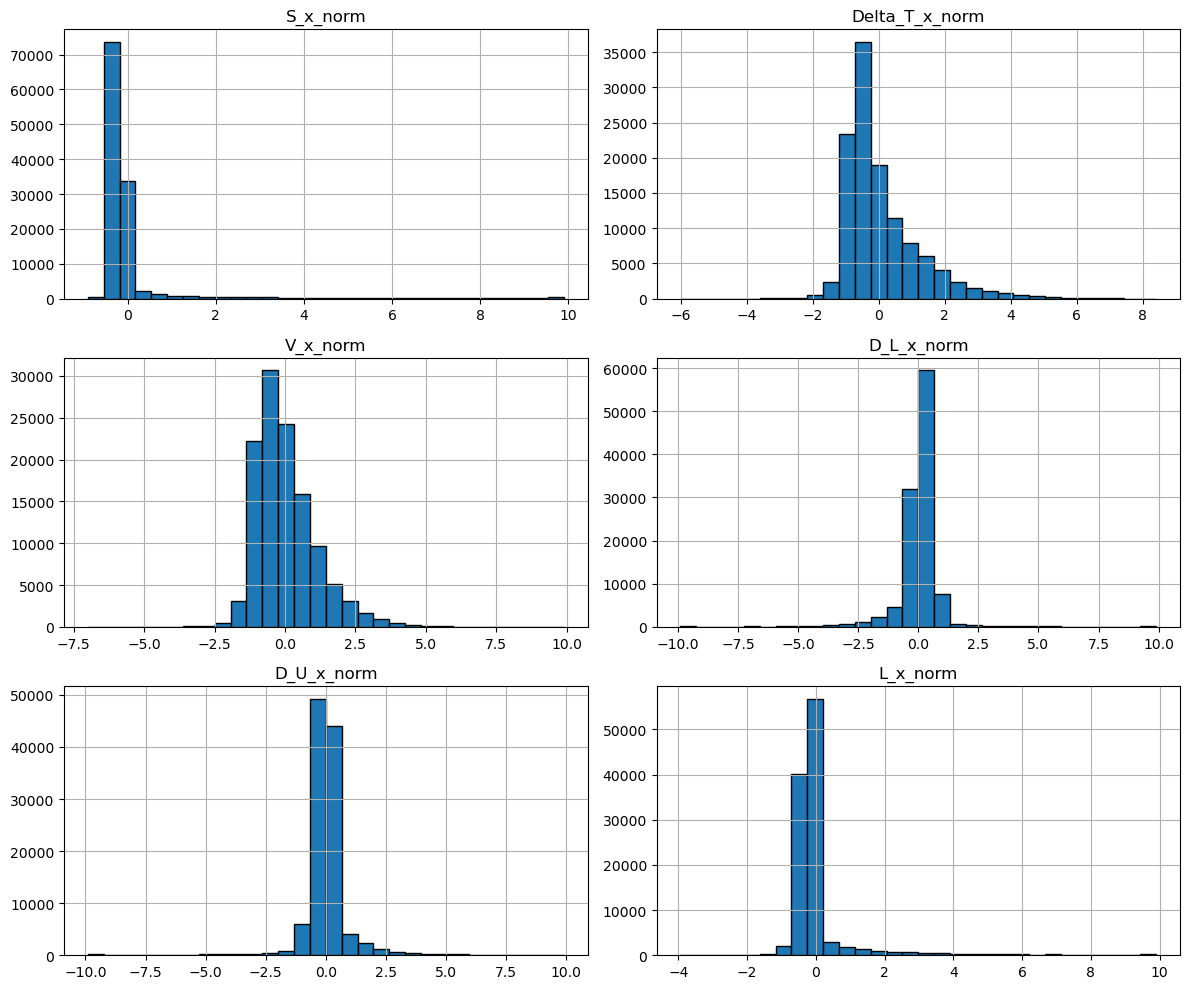

In [5]:
# feature visualization: distribution
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

plt.rcParams["figure.figsize"] = (6, 4)

df = pd.read_csv("data_feature/data_norm_features.csv")
numeric_cols = ['S_x_norm', 'Delta_T_x_norm', 'V_x_norm', 'D_L_x_norm', 'D_U_x_norm', 'L_x_norm']

df[numeric_cols].hist(figsize=(12, 10), bins=30, edgecolor="black")
plt.tight_layout()
plt.show()

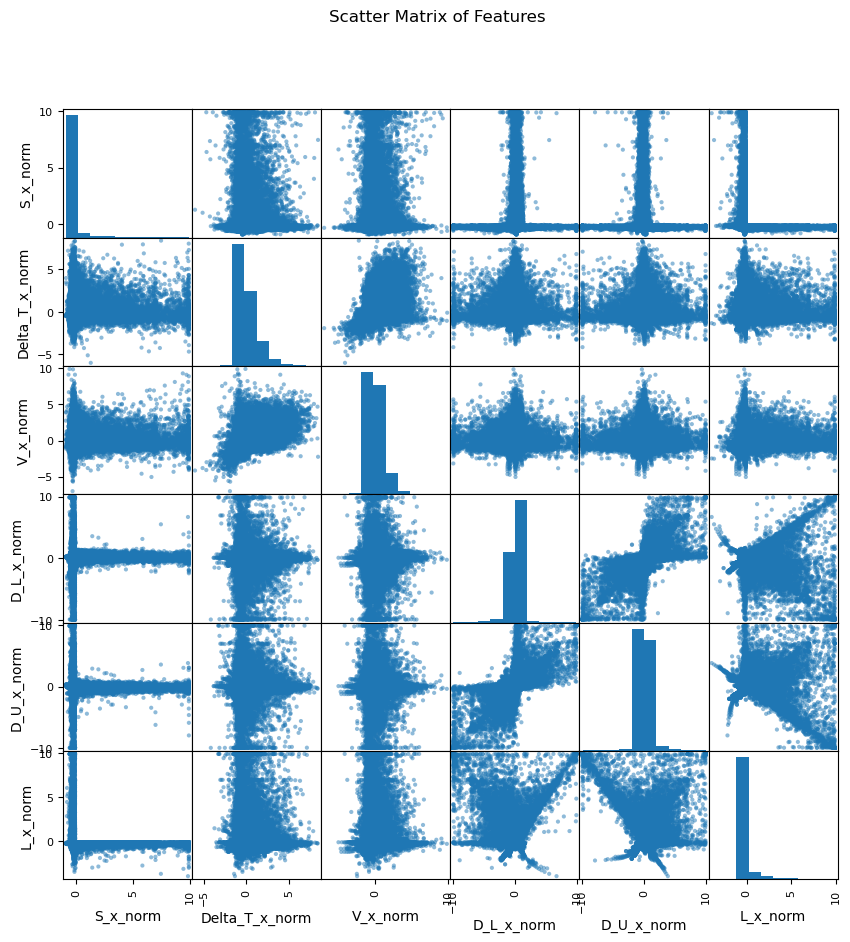

In [6]:
# feature visualization: scatter matrix
scatter_matrix(df[numeric_cols], diagonal="hist", figsize=(10, 10))
plt.suptitle("Scatter Matrix of Features")
plt.show()

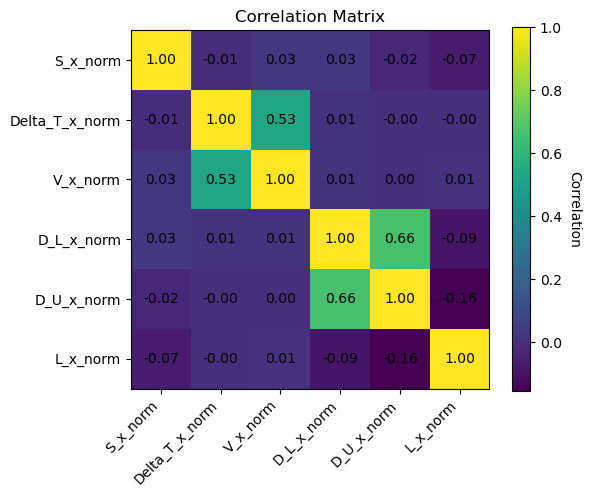

In [7]:
# Correlation Matrix of Features
numeric_cols = ['S_x_norm', 'Delta_T_x_norm', 'V_x_norm', 'D_L_x_norm', 'D_U_x_norm', 'L_x_norm']

corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(corr, interpolation="nearest")

cbar = plt.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Correlation", rotation=-90, va="bottom")

ax.set_xticks(np.arange(len(numeric_cols)))
ax.set_yticks(np.arange(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha="right")
ax.set_yticklabels(numeric_cols)

ax.set_title("Correlation Matrix")

for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        value = corr.iloc[i, j]
        text = f"{value:.2f}"
        ax.text(j, i, text,
                ha="center", va="center")

plt.tight_layout()
plt.show()

In [57]:
# calculate dependent variables: CONR, FRNB and HPNL
data_with_clusters = pd.read_csv("data_feature/data_norm_features.csv")
df_lp_features = calculate_dependent_variables(
    data_with_clusters,
    fee_tier,
    decimal_0,
    decimal_1,
    token0,
    token1,
    base_symbol
)
df_lp_features.to_csv("data_feature/data_with_variables.csv", index=False)
df_lp_features[df_lp_features['event'].isin(['Mint', 'Burn'])]

,datetime,blockNumber,event,WETH,USDC,amount,tick,price,liquidity,tickLower,...,Delta_T_x_norm,V_x_norm,D_L_x_norm,D_U_x_norm,L_x_norm,CONR,FRNB,HPNL,HPNL_Fee,HPNL_IL
54,2024-09-01 00:16:01,248790511.0,Burn,0.000000,0.000000,0.000000e+00,NaN,NaN,NaN,-198610.0,...,0.926593,0.241216,-0.046383,-0.238414,-0.429158,-0.002900,-0.004500,0.000000e+00,0.000000e+00,0.000000e+00
58,2024-09-01 00:16:42,248790675.0,Burn,0.000000,0.000000,0.000000e+00,NaN,NaN,NaN,-198620.0,...,-0.881999,-1.043135,-0.046383,-0.238414,-0.429158,-0.002900,-0.004500,0.000000e+00,0.000000e+00,0.000000e+00
60,2024-09-01 00:17:07,248790774.0,Burn,0.000000,0.000000,0.000000e+00,NaN,NaN,NaN,-197790.0,...,-0.799629,-1.026018,0.204979,0.398111,0.153626,-0.002900,-0.004500,0.000000e+00,0.000000e+00,0.000000e+00
61,2024-09-01 00:17:41,248790907.0,Burn,0.000000,0.000000,0.000000e+00,NaN,NaN,NaN,-198630.0,...,-0.693587,-1.009333,-0.048913,-0.244718,-0.435401,-0.002900,-0.004500,0.000000e+00,0.000000e+00,0.000000e+00
64,2024-09-01 00:18:13,248791034.0,Burn,0.000000,0.000000,0.000000e+00,NaN,NaN,NaN,-198640.0,...,-0.588127,-0.989310,-0.097768,-0.276220,-0.419235,-0.002900,-0.004500,0.000000e+00,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4584914,2025-08-31 22:37:48,374364235.0,Mint,0.233091,3094.698019,1.557618e+14,NaN,NaN,NaN,-199360.0,...,0.041585,-0.212966,0.100000,0.100000,-0.100000,-0.005600,-0.011899,-2.719242e-15,9.585739e-16,-3.677816e-15
4584972,2025-08-31 22:46:10,374366242.0,Burn,0.046371,197.295037,6.488811e+13,NaN,NaN,NaN,-193260.0,...,-0.078225,1.064293,0.100000,0.100000,-0.100000,-0.005600,-0.011899,-1.409825e-15,8.968197e-16,-2.306645e-15
4585119,2025-08-31 23:06:14,374371058.0,Burn,0.000000,0.000000,0.000000e+00,NaN,NaN,NaN,-193180.0,...,-0.910584,-0.338434,0.100000,0.100000,-0.100000,-0.011899,NaN,0.000000e+00,0.000000e+00,0.000000e+00
4585121,2025-08-31 23:06:14,374371058.0,Mint,0.000658,2.023982,7.434352e+11,NaN,NaN,NaN,-193180.0,...,-0.899839,-0.330132,0.100000,0.100000,-0.100000,-0.011899,NaN,-9.190054e-16,7.046232e-16,-1.623629e-15


In [58]:
# separate train and test data sets
start_date, end_date = pd.to_datetime(["2024-09-01T00:00:00", "2025-03-01T00:00:00"])
df_train = df_lp_features[
    (df_lp_features['datetime'] >= start_date) & 
    (df_lp_features['datetime'] < end_date)
].copy()

start_date, end_date = pd.to_datetime(["2025-03-01T00:00:00", "2025-09-01T00:00:00"])
df_test = df_lp_features[
    (df_lp_features['datetime'] >= start_date) & 
    (df_lp_features['datetime'] < end_date)
].copy()

df_train.to_csv('data_feature/data_train.csv', index=False)
df_test.to_csv('data_feature/data_test.csv', index=False)

### Clustering
* model: KMeans++

In [59]:
# K-means Clustering: K=3
df_cluster, kmeans_model_k3 = run_kmeans_clustering(
    trained_model=None,
    input_path="data_feature/data_train.csv",
    output_path="data_feature/data_train_clusters_k3.csv",
    K=3)
df_cluster[df_cluster['event'].isin(['Mint', 'Burn'])]

,datetime,blockNumber,event,WETH,USDC,amount,tick,price,liquidity,tickLower,...,V_x_norm,D_L_x_norm,D_U_x_norm,L_x_norm,CONR,FRNB,HPNL,HPNL_Fee,HPNL_IL,Cluster_Label
54,2024-09-01 00:16:01,248790511.0,Burn,0.000000,0.0000,0.000000e+00,NaN,NaN,NaN,-198610.0,...,0.241216,-0.046383,-0.238414,-0.429158,-0.0029,-0.0045,0.000000e+00,0.000000e+00,0.000000e+00,0.0
58,2024-09-01 00:16:42,248790675.0,Burn,0.000000,0.0000,0.000000e+00,NaN,NaN,NaN,-198620.0,...,-1.043135,-0.046383,-0.238414,-0.429158,-0.0029,-0.0045,0.000000e+00,0.000000e+00,0.000000e+00,1.0
60,2024-09-01 00:17:07,248790774.0,Burn,0.000000,0.0000,0.000000e+00,NaN,NaN,NaN,-197790.0,...,-1.026018,0.204979,0.398111,0.153626,-0.0029,-0.0045,0.000000e+00,0.000000e+00,0.000000e+00,1.0
61,2024-09-01 00:17:41,248790907.0,Burn,0.000000,0.0000,0.000000e+00,NaN,NaN,NaN,-198630.0,...,-1.009333,-0.048913,-0.244718,-0.435401,-0.0029,-0.0045,0.000000e+00,0.000000e+00,0.000000e+00,1.0
64,2024-09-01 00:18:13,248791034.0,Burn,0.000000,0.0000,0.000000e+00,NaN,NaN,NaN,-198640.0,...,-0.989310,-0.097768,-0.276220,-0.419235,-0.0029,-0.0045,0.000000e+00,0.000000e+00,0.000000e+00,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2627350,2025-02-28 22:33:41,310926801.0,Burn,0.000000,0.0000,0.000000e+00,NaN,NaN,NaN,-199740.0,...,0.526508,-0.218756,-0.371563,-0.257576,-0.0043,0.0096,0.000000e+00,0.000000e+00,0.000000e+00,1.0
2627597,2025-02-28 22:46:32,310929842.0,Mint,0.000271,3.6400,1.687476e+12,NaN,NaN,NaN,-200220.0,...,1.619702,-0.218756,-0.371563,-0.257576,-0.0043,0.0096,-3.170648e-16,5.983426e-16,-9.154074e-16,0.0
2627598,2025-02-28 22:46:32,310929842.0,Mint,0.022962,10.9200,1.809723e+13,NaN,NaN,NaN,-199540.0,...,1.581459,-0.218756,-0.371563,-0.257576,-0.0043,0.0096,-3.170648e-16,5.983426e-16,-9.154074e-16,0.0
2627599,2025-02-28 22:46:32,310929842.0,Mint,0.000004,3.6400,2.001237e+12,NaN,NaN,NaN,-200070.0,...,1.546123,-0.218756,-0.371563,-0.257576,-0.0043,0.0096,2.175470e-16,2.788973e-16,-6.135036e-17,0.0


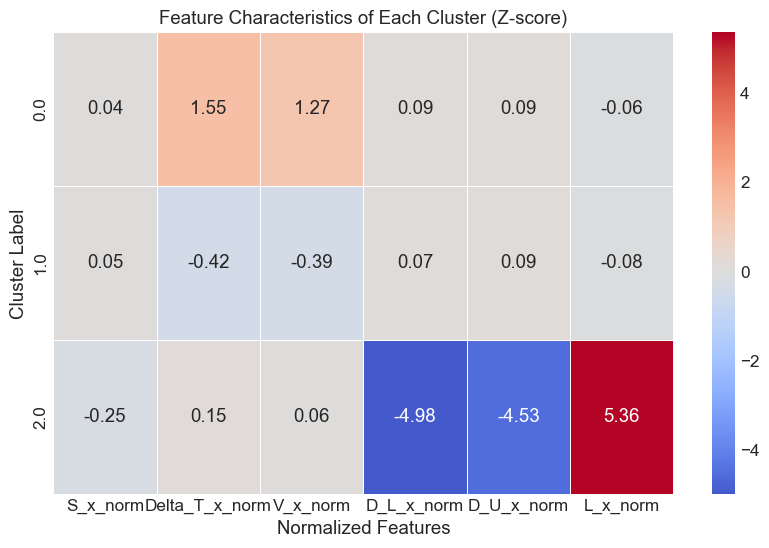

Cluster Distribution:
Cluster_Label
0.0    16180
1.0    48382
2.0     1093
Name: count, dtype: int64


In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filter data with cluster labels (Mint/Burn events only)
df_only_lp = df_cluster[df_cluster['event'].isin(['Mint', 'Burn'])].copy()

# 2. Calculate cluster centroids
# Compute the mean for the 6 normalized features used during clustering
features_col = ['S_x_norm', 'Delta_T_x_norm', 'V_x_norm', 'D_L_x_norm', 'D_U_x_norm', 'L_x_norm']
centroids = df_only_lp.groupby('Cluster_Label')[features_col].mean()

# 3. Plot the Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    centroids,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    linewidths=.5
)

plt.title('Feature Characteristics of Each Cluster (Z-score)')
plt.xlabel('Normalized Features')
plt.ylabel('Cluster Label')
plt.show()

# 4. Print sample distribution per cluster
print("Cluster Distribution:")
print(df_only_lp['Cluster_Label'].value_counts().sort_index())

c:\Users\shihf\AMM_analysis\ClusterLOB\clustering.py:197: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  [pd.Grouper(key=time_col, freq=freq), cluster_col]
c:\Users\shihf\AMM_analysis\ClusterLOB\clustering.py:209: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  [pd.date_range(min_time, max_time, freq=freq, name=time_col), all_clusters],
c:\Users\shihf\AMM_analysis\ClusterLOB\clustering.py:244: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  [pd.Grouper(key=time_col, freq='1H'), cluster_col]


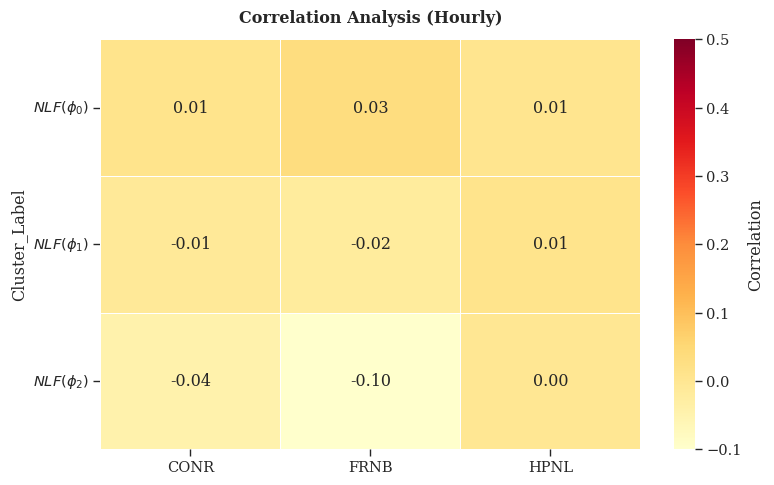

,CONR,FRNB,HPNL
Cluster_Label,,,
0.0,0.011100,0.034061,0.005754
1.0,-0.009569,-0.018481,0.010796
2.0,-0.044899,-0.100366,0.000286


In [61]:
corr_matrix = analyze_and_plot_correlations(
    df_cluster,
    time_col='datetime', 
    cluster_col='Cluster_Label',
    amount_col='amount',  
    type_col='event',    
    freq='1H'               
)
corr_matrix

c:\Users\shihf\AMM_analysis\ClusterLOB\clustering.py:197: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  [pd.Grouper(key=time_col, freq=freq), cluster_col]
c:\Users\shihf\AMM_analysis\ClusterLOB\clustering.py:209: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  [pd.date_range(min_time, max_time, freq=freq, name=time_col), all_clusters],



[Data Diagnostics]
Cluster 0.0: Total Hours 2980, Active Hours 2394 (80.3%)
Cluster 1.0: Total Hours 3966, Active Hours 3633 (91.6%)
Cluster 2.0: Total Hours 624, Active Hours 553 (88.6%)


c:\Users\shihf\AMM_analysis\ClusterLOB\clustering.py:323: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  [pd.Grouper(key=time_col, freq='1H'), cluster_col]


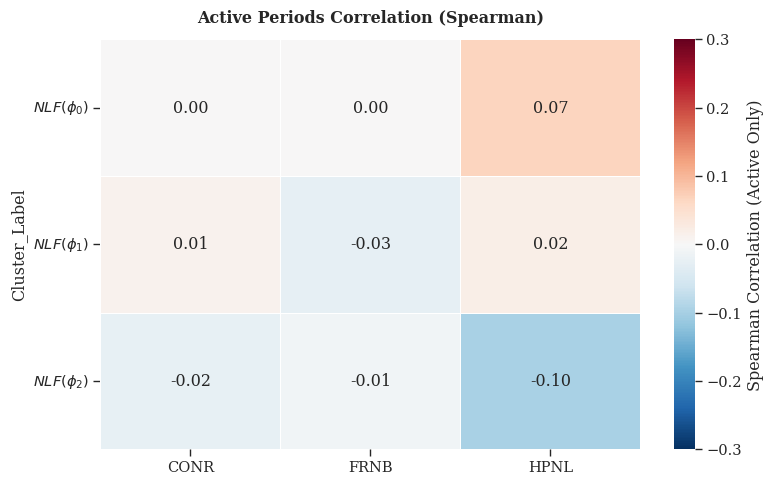

,CONR,FRNB,HPNL
Cluster_Label,,,
0.0,0.001142,0.002025,0.065917
1.0,0.013004,-0.026197,0.020019
2.0,-0.023700,-0.010317,-0.097937


In [62]:
corr_matrix = analyze_and_plot_robust_correlations(
    df_cluster,
    time_col='datetime', 
    cluster_col='Cluster_Label',
    amount_col='amount',  
    type_col='event',    
    freq='1H'               
)
corr_matrix

In [132]:
metrics_df = analyze_cluster_performance(
    raw_df=df_cluster,
    time_col='datetime',
    cluster_col='Cluster_Label',
    hpnl_col='HPNL',
    target_vol=0.15
)


Cluster         Sharpe     Sortino    Calmar     Max DD     Win Rate  
0.0                 0.19      0.12      0.19    -15.0%     71.3%
1.0                -0.01     -0.01     -0.02     -8.5%     68.0%
2.0                 0.27      0.06      0.32    -12.3%     11.0%
No Cluster          0.12      0.07      0.19     -9.4%     71.8%


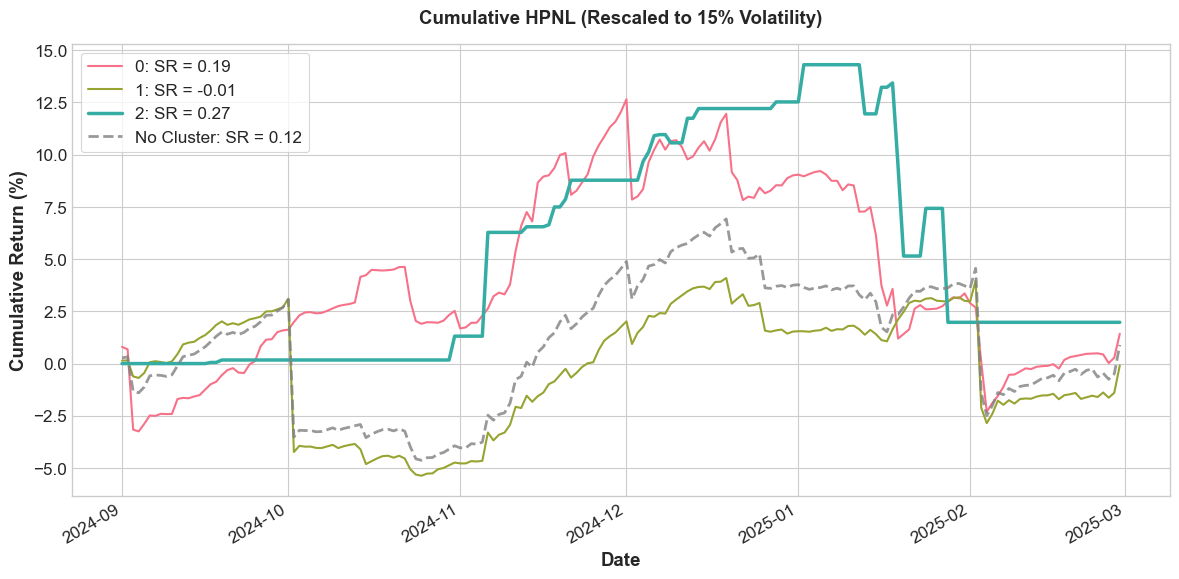

In [64]:
# calculate sharpe ratio
sr_results, pnl_df = calculate_sharpe_and_plot(
    raw_df=df_cluster, 
    time_col='datetime', 
    cluster_col='Cluster_Label', 
    hpnl_col='HPNL',
    target_vol=0.15
)

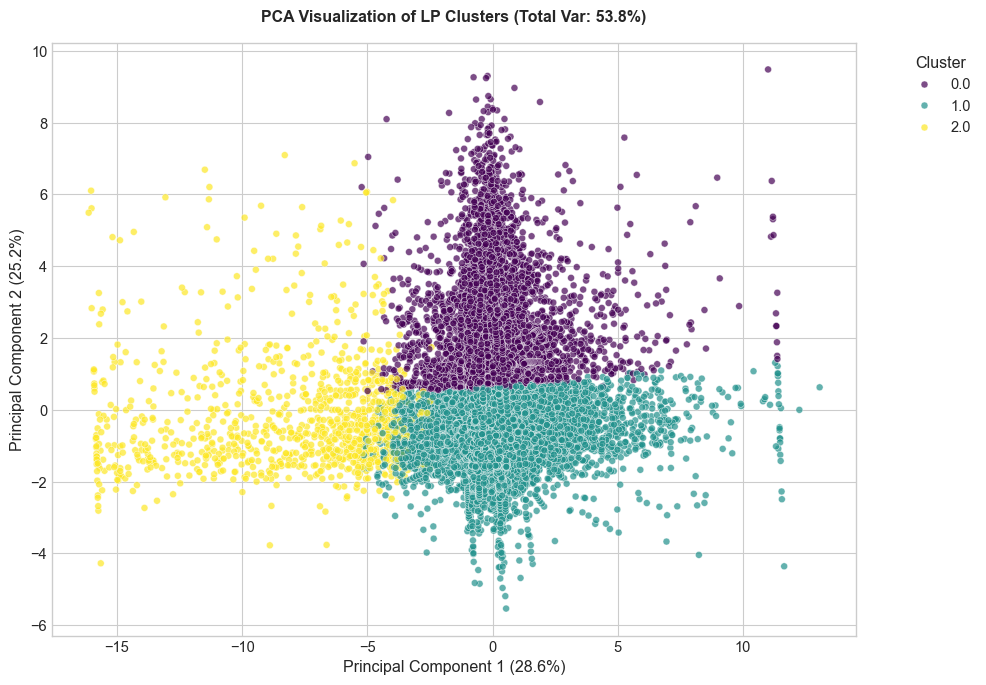

In [65]:
# PCA
pca_result = plot_pca_clusters(df_cluster)

* test set clustering, using the trained model from training set

In [67]:
# K-means Clustering, K=3, using the trained model
df_cluster, kmeans_model_k3 = run_kmeans_clustering(
    trained_model=kmeans_model_k3,
    input_path="data_feature/data_with_variables_test.csv",
    output_path="data_feature/data_test_clusters_k3.csv",
    K=3)
df_cluster[df_cluster['event'].isin(['Mint', 'Burn'])]

,datetime,blockNumber,event,WETH,USDC,amount,tick,price,liquidity,tickLower,...,V_x_norm,D_L_x_norm,D_U_x_norm,L_x_norm,CONR,FRNB,HPNL,HPNL_Fee,HPNL_IL,Cluster_Label
178,2025-03-01 00:20:05,310951927.0,Mint,0.000129,4.836136,2.037023e+12,NaN,NaN,NaN,-200220.0,...,-0.932737,-0.218756,-0.371563,-0.229743,-0.009100,0.016299,2.646281e-16,8.073824e-16,-5.427543e-16,1.0
179,2025-03-01 00:20:05,310951927.0,Mint,0.020713,14.508410,1.768328e+13,NaN,NaN,NaN,-199540.0,...,-0.914883,-0.218756,-0.371563,-0.229743,-0.009100,0.016299,3.695965e-16,9.181639e-16,-5.485674e-16,1.0
180,2025-03-01 00:20:05,310951927.0,Mint,0.000000,4.836136,2.651952e+12,NaN,NaN,NaN,-200070.0,...,-0.912279,-1.772496,-0.437568,-0.140798,-0.009100,0.016299,1.147541e-16,1.147541e-16,0.000000e+00,1.0
225,2025-03-01 00:23:07,310952652.0,Mint,0.000010,0.342126,1.449464e+11,NaN,NaN,NaN,-200220.0,...,-0.353038,-0.199545,-0.370794,-0.230681,-0.009100,0.016299,1.334648e-16,7.598567e-16,-6.263919e-16,1.0
226,2025-03-01 00:23:07,310952652.0,Mint,0.001498,1.026379,1.272315e+12,NaN,NaN,NaN,-199540.0,...,-0.363086,-0.181010,-0.353421,-0.216489,-0.009100,0.016299,2.384332e-16,8.706382e-16,-6.322050e-16,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1956730,2025-08-31 22:37:48,374364235.0,Mint,0.233091,3094.698019,1.557618e+14,NaN,NaN,NaN,-199360.0,...,-0.212966,0.100000,0.100000,-0.100000,-0.005600,-0.011899,-2.719242e-15,9.585739e-16,-3.677816e-15,1.0
1956788,2025-08-31 22:46:10,374366242.0,Burn,0.046371,197.295037,6.488811e+13,NaN,NaN,NaN,-193260.0,...,1.064293,0.100000,0.100000,-0.100000,-0.005600,-0.011899,-1.409825e-15,8.968197e-16,-2.306645e-15,1.0
1956935,2025-08-31 23:06:14,374371058.0,Burn,0.000000,0.000000,0.000000e+00,NaN,NaN,NaN,-193180.0,...,-0.338434,0.100000,0.100000,-0.100000,-0.011899,NaN,0.000000e+00,0.000000e+00,0.000000e+00,1.0
1956937,2025-08-31 23:06:14,374371058.0,Mint,0.000658,2.023982,7.434352e+11,NaN,NaN,NaN,-193180.0,...,-0.330132,0.100000,0.100000,-0.100000,-0.011899,NaN,-9.190054e-16,7.046232e-16,-1.623629e-15,1.0


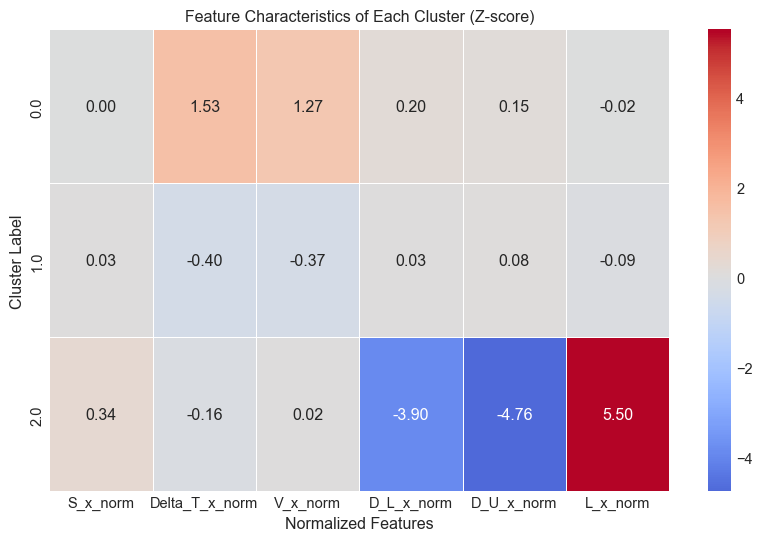

Cluster Distribution:
Cluster_Label
0.0    10647
1.0    33714
2.0      901
Name: count, dtype: int64


In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filter data with cluster labels (Mint/Burn events only)
df_only_lp = df_cluster[df_cluster['event'].isin(['Mint', 'Burn'])].copy()

# 2. Calculate cluster centroids
# Compute the mean for the 6 normalized features used during clustering
features_col = ['S_x_norm', 'Delta_T_x_norm', 'V_x_norm', 'D_L_x_norm', 'D_U_x_norm', 'L_x_norm']
centroids = df_only_lp.groupby('Cluster_Label')[features_col].mean()

# 3. Plot the Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    centroids,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    linewidths=.5
)

plt.title('Feature Characteristics of Each Cluster (Z-score)')
plt.xlabel('Normalized Features')
plt.ylabel('Cluster Label')
plt.show()

# 4. Print sample distribution per cluster
print("Cluster Distribution:")
print(df_only_lp['Cluster_Label'].value_counts().sort_index())

c:\Users\shihf\AMM_analysis\ClusterLOB\clustering.py:197: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  [pd.Grouper(key=time_col, freq=freq), cluster_col]
c:\Users\shihf\AMM_analysis\ClusterLOB\clustering.py:209: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  [pd.date_range(min_time, max_time, freq=freq, name=time_col), all_clusters],
c:\Users\shihf\AMM_analysis\ClusterLOB\clustering.py:244: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  [pd.Grouper(key=time_col, freq='1H'), cluster_col]


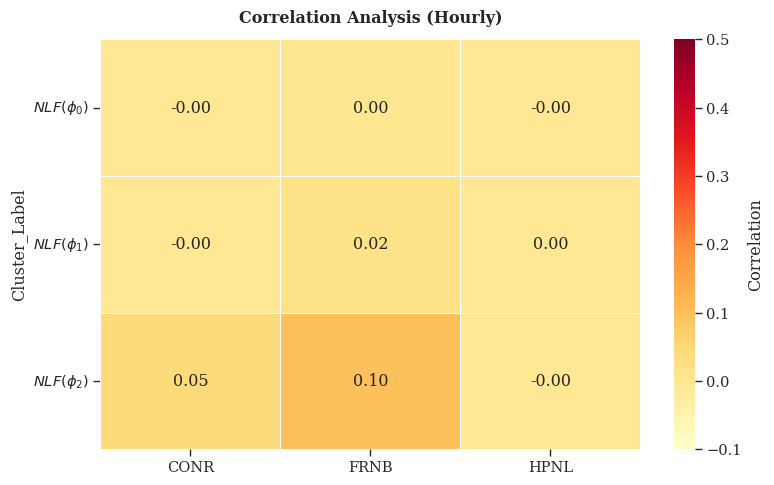

,CONR,FRNB,HPNL
Cluster_Label,,,
0.0,-0.003225,0.002636,-0.000577
1.0,-0.002570,0.017684,0.000498
2.0,0.045156,0.098115,-0.002527


In [69]:
corr_matrix = analyze_and_plot_correlations(
    df_cluster,
    time_col='datetime', 
    cluster_col='Cluster_Label',
    amount_col='amount',  
    type_col='event',    
    freq='1H'               
)
corr_matrix

c:\Users\shihf\AMM_analysis\ClusterLOB\clustering.py:197: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  [pd.Grouper(key=time_col, freq=freq), cluster_col]
c:\Users\shihf\AMM_analysis\ClusterLOB\clustering.py:209: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  [pd.date_range(min_time, max_time, freq=freq, name=time_col), all_clusters],



[Data Diagnostics]
Cluster 0.0: Total Hours 2363, Active Hours 1680 (71.1%)
Cluster 1.0: Total Hours 3628, Active Hours 3080 (84.9%)
Cluster 2.0: Total Hours 405, Active Hours 373 (92.1%)


c:\Users\shihf\AMM_analysis\ClusterLOB\clustering.py:323: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  [pd.Grouper(key=time_col, freq='1H'), cluster_col]


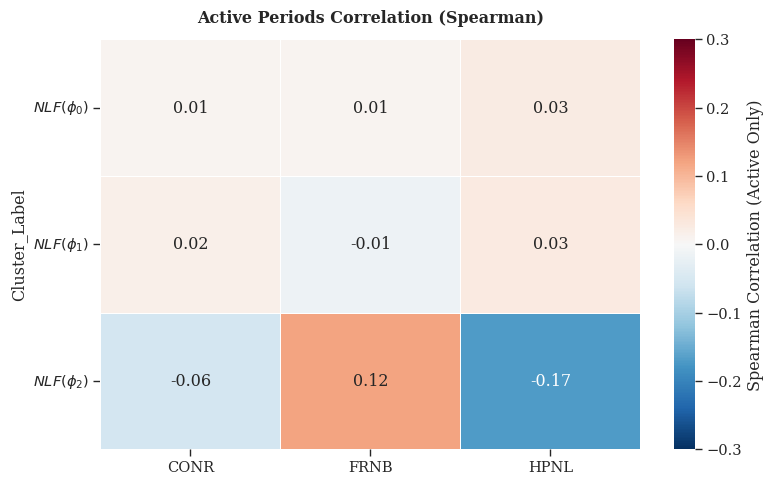

,CONR,FRNB,HPNL
Cluster_Label,,,
0.0,0.008432,0.007385,0.025451
1.0,0.018150,-0.014452,0.026496
2.0,-0.055418,0.121773,-0.169896


In [70]:
corr_matrix = analyze_and_plot_robust_correlations(
    df_cluster,
    time_col='datetime', 
    cluster_col='Cluster_Label',
    amount_col='amount',  
    type_col='event',    
    freq='1H'               
)
corr_matrix

In [135]:
metrics_df = analyze_cluster_performance(
    raw_df=df_cluster,
    time_col='datetime',
    cluster_col='Cluster_Label',
    hpnl_col='HPNL',
    target_vol=0.15
)


Cluster         Sharpe     Sortino    Calmar     Max DD     Win Rate  
0.0                -0.59     -0.34     -0.83    -10.7%     72.3%
1.0                -0.92     -0.62     -1.52     -9.1%     65.8%
2.0                -0.29     -0.04     -0.36    -12.3%      9.2%
No Cluster         -0.46     -0.33     -0.82     -8.4%     64.7%


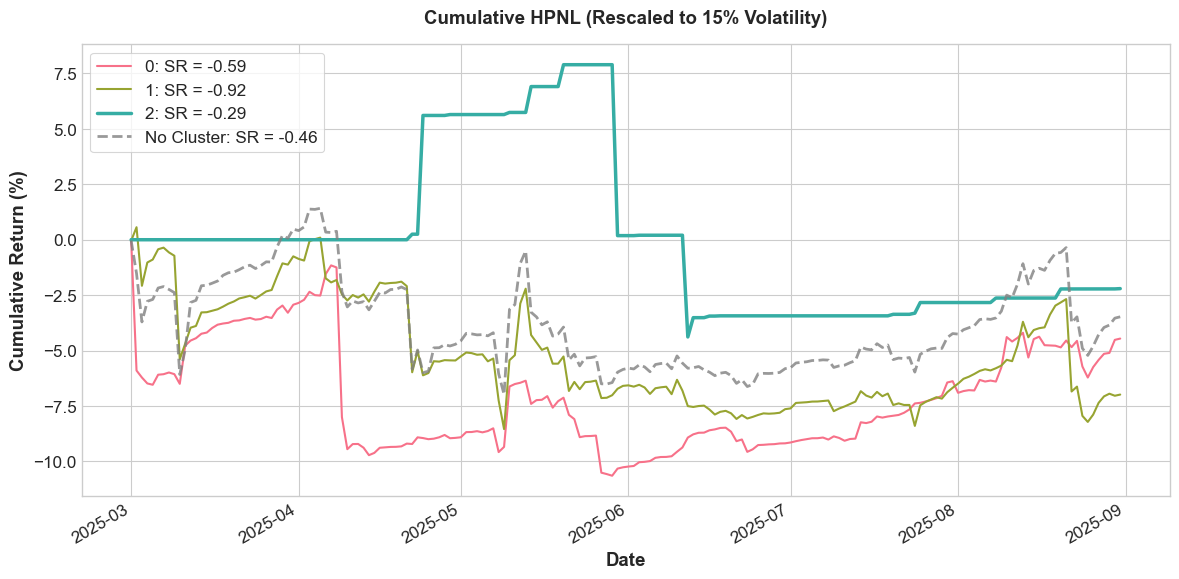

In [134]:
sr_results, pnl_df = calculate_sharpe_and_plot(
    raw_df=df_cluster, 
    time_col='datetime', 
    cluster_col='Cluster_Label', 
    hpnl_col='HPNL',
    target_vol=0.15
)

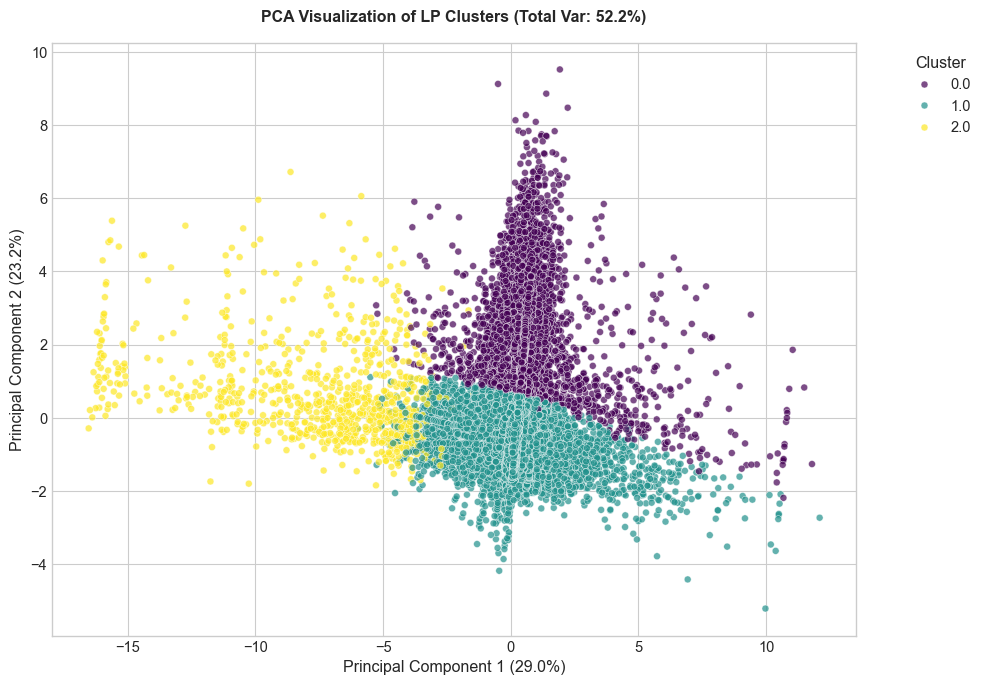

In [73]:
# PCA
pca_result = plot_pca_clusters(df_cluster)

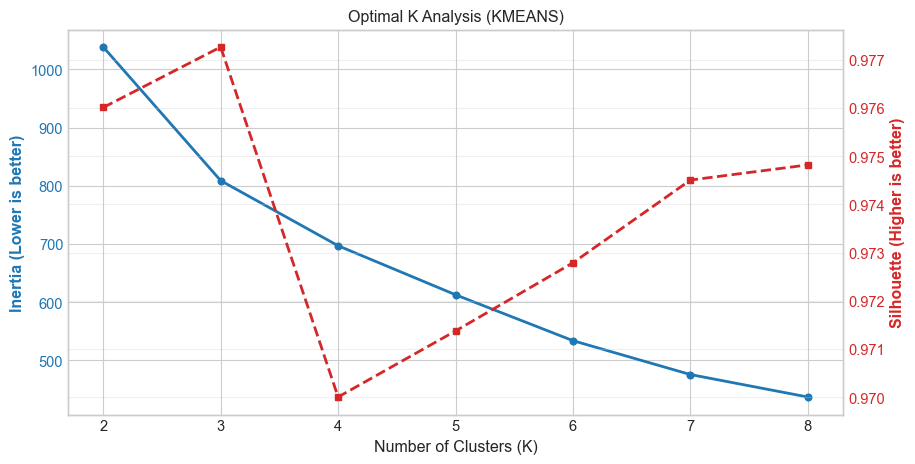

In [74]:
input_csv = "data_feature/data_norm_features.csv"
analyze_optimal_k(input_csv, model_type='kmeans')

c:\Users\shihf\anaconda3\envs\islp_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


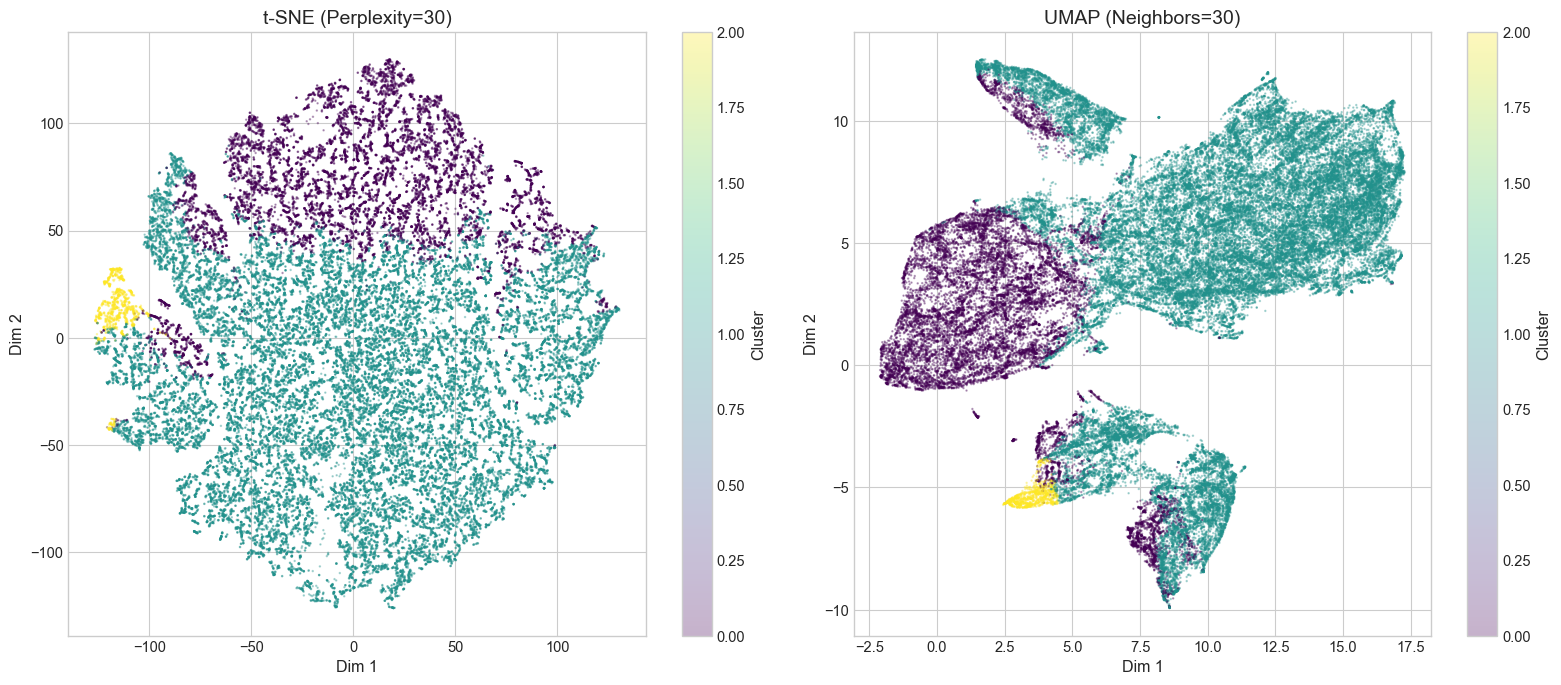

In [75]:
# Visualize Cluster data: UMAP and t-SNE
visualize_clusters("data_feature/data_train_clusters_k3.csv")